In [147]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### LOAD DATASET

In [148]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [149]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [150]:
df.tail()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754
2639,2018,8,North America,Model S,2639,2929,51676.24,82,474,187.63,Estimated (Region),14297


In [151]:
df.shape

(2640, 12)

In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


In [153]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,2640.0,2020.000000,3.162877,2015.00,2017.000,2020.000,2023.0000,2025.00
Month,2640.0,6.500000,3.452707,1.00,3.750,6.500,9.2500,12.00
Estimated_Deliveries,2640.0,9922.199621,3935.950093,48.00,7292.000,9857.000,12510.2500,25704.00
Production_Units,2640.0,10655.847348,4260.600858,50.00,7828.250,10546.500,13469.0000,28939.00
Avg_Price_USD,2640.0,84907.340330,20123.258036,50003.70,67726.365,85058.510,102373.0425,119965.36
Battery_Capacity_kWh,2640.0,87.059470,20.836265,60.00,75.000,82.000,100.0000,120.00
Range_km,2640.0,500.257576,120.868549,330.00,418.000,470.000,586.2500,719.00
CO2_Saved_tons,2640.0,744.076989,353.221224,3.07,499.620,699.515,943.7650,2548.55
Charging_Stations,2640.0,8932.133712,3469.565883,3002.00,5897.750,8901.500,11938.0000,14996.00


### DATA CLEANING

In [154]:
df.isnull().sum()

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [155]:
df.duplicated().sum()

np.int64(0)

In [156]:
for col in df.select_dtypes(include="object"):
    print(f"\n{col}")
    print(df[col].unique())


Region
<StringArray>
['Europe', 'Asia', 'North America', 'Middle East']
Length: 4, dtype: str

Model
<StringArray>
['Model S', 'Model X', 'Model 3', 'Model Y', 'Cybertruck']
Length: 5, dtype: str

Source_Type
<StringArray>
['Interpolated (Month)', 'Official (Quarter)', 'Estimated (Region)']
Length: 3, dtype: str


In [157]:
df.select_dtypes(include=np.number).columns

Index(['Year', 'Month', 'Estimated_Deliveries', 'Production_Units',
       'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations'],
      dtype='str')

In [158]:
df.select_dtypes(include="object").columns

Index(['Region', 'Model', 'Source_Type'], dtype='str')

In [159]:
df.dtypes

Year                      int64
Month                     int64
Region                      str
Model                       str
Estimated_Deliveries      int64
Production_Units          int64
Avg_Price_USD           float64
Battery_Capacity_kWh      int64
Range_km                  int64
CO2_Saved_tons          float64
Source_Type                 str
Charging_Stations         int64
dtype: object

In [160]:
df["Year"] = df["Year"].astype(int)
df["Month"] = df["Month"].astype(int)

In [161]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str) + "-" +
    df["Month"].astype(str) + "-01"
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,2016-12-01


In [162]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]

    print(f"{col}: {len(outliers)} outliers")

Year: 0 outliers
Month: 0 outliers
Estimated_Deliveries: 12 outliers
Production_Units: 12 outliers
Avg_Price_USD: 0 outliers
Battery_Capacity_kWh: 0 outliers
Range_km: 0 outliers
CO2_Saved_tons: 45 outliers
Charging_Stations: 0 outliers


### EDA

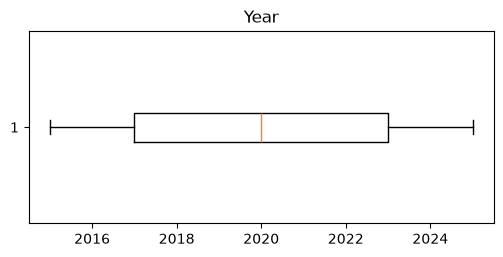

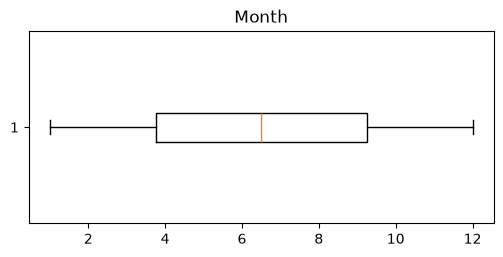

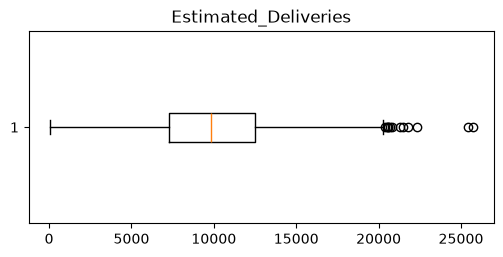

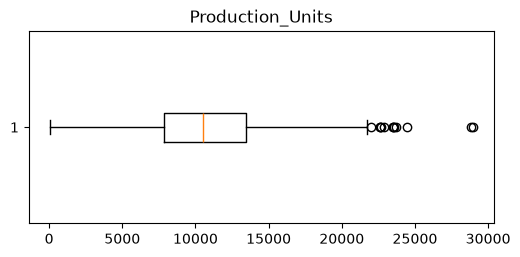

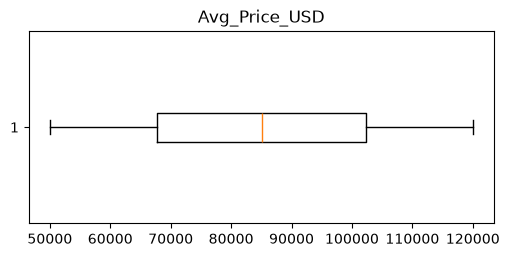

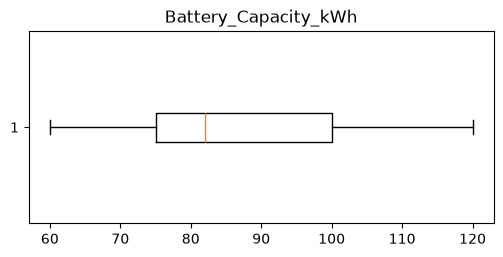

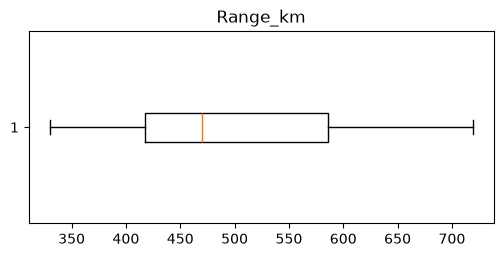

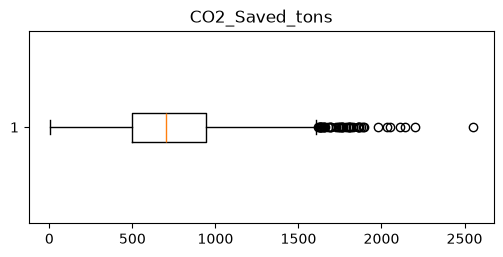

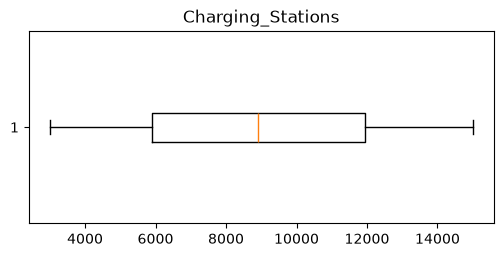

In [163]:
for col in num_cols:
    plt.figure(figsize=(6,2.5))
    plt.boxplot(df[col], vert=False)
    plt.title(col)
    plt.show()

In [164]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

In [165]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year                  2640 non-null   int64         
 1   Month                 2640 non-null   int64         
 2   Region                2640 non-null   str           
 3   Model                 2640 non-null   str           
 4   Estimated_Deliveries  2640 non-null   float64       
 5   Production_Units      2640 non-null   float64       
 6   Avg_Price_USD         2640 non-null   float64       
 7   Battery_Capacity_kWh  2640 non-null   int64         
 8   Range_km              2640 non-null   int64         
 9   CO2_Saved_tons        2640 non-null   float64       
 10  Source_Type           2640 non-null   str           
 11  Charging_Stations     2640 non-null   int64         
 12  Date                  2640 non-null   datetime64[us]
dtypes: datetime64[us](1), float64

In [166]:
corr = df.select_dtypes(include=np.number).corr()
corr

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
Year,1.000000e+00,2.216119e-15,-0.001381,-0.001295,-0.004991,-0.030486,-0.029128,-0.015086,-0.003466
Month,2.216119e-15,1.000000e+00,0.030730,0.028867,0.024857,0.001714,0.002143,0.029641,-0.011325
Estimated_Deliveries,-1.380873e-03,3.072978e-02,1.000000,0.994312,-0.026679,-0.007531,-0.006243,0.839164,0.001451
Production_Units,-1.294525e-03,2.886702e-02,0.994312,1.000000,-0.028129,-0.003574,-0.002140,0.837003,0.001100
Avg_Price_USD,-4.990980e-03,2.485676e-02,-0.026679,-0.028129,1.000000,-0.018203,-0.017854,-0.028752,-0.017790
Battery_Capacity_kWh,-3.048584e-02,1.714479e-03,-0.007531,-0.003574,-0.018203,1.000000,0.994313,0.497754,-0.005834
Range_km,-2.912765e-02,2.142889e-03,-0.006243,-0.002140,-0.017854,0.994313,1.000000,0.501879,-0.008291
CO2_Saved_tons,-1.508552e-02,2.964140e-02,0.839164,0.837003,-0.028752,0.497754,0.501879,1.000000,-0.004301
Charging_Stations,-3.465622e-03,-1.132526e-02,0.001451,0.001100,-0.017790,-0.005834,-0.008291,-0.004301,1.000000


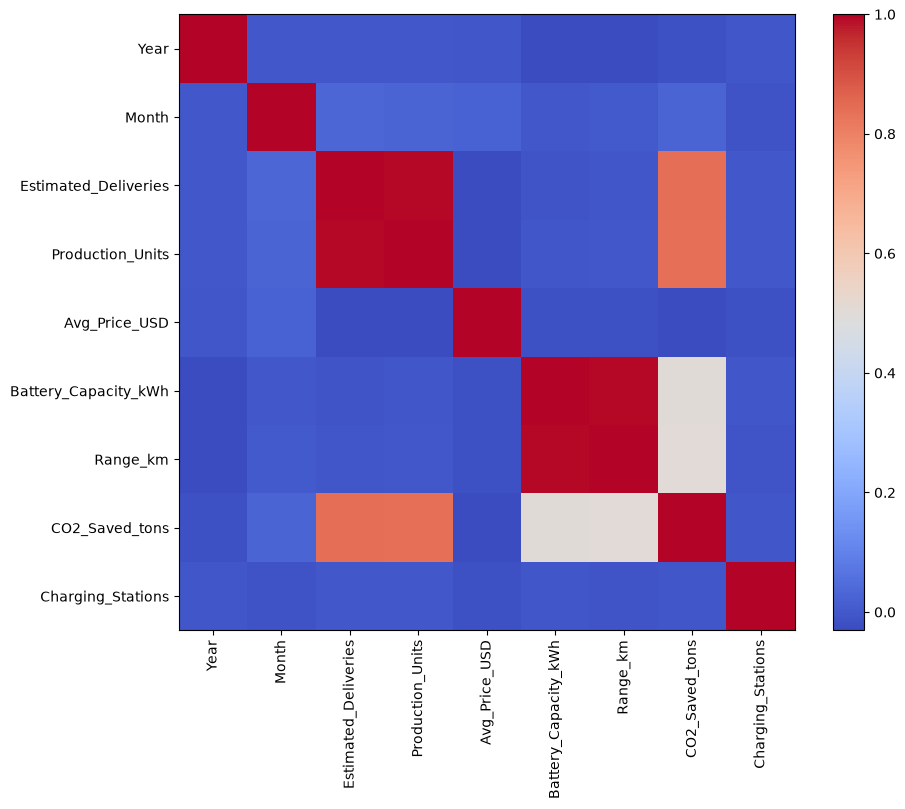

In [167]:
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap="coolwarm")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

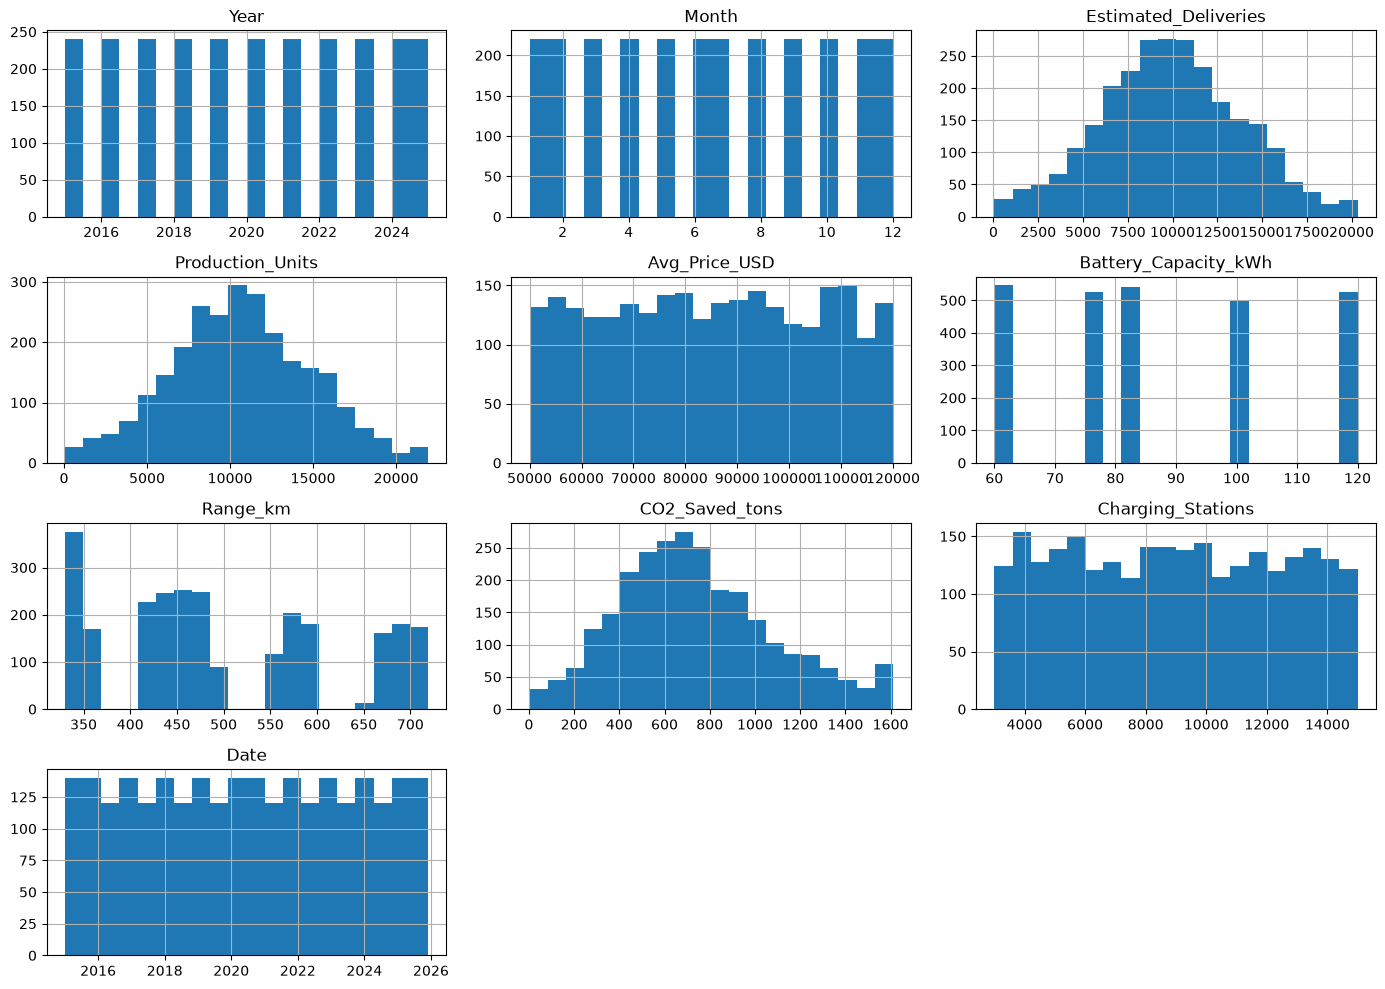

In [168]:
df.hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

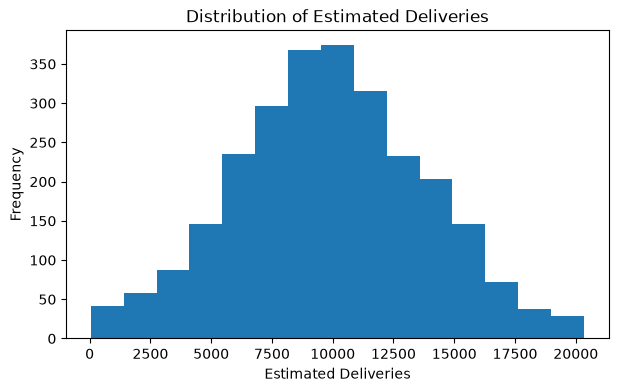

In [169]:
plt.figure(figsize=(7,4))
plt.hist(df["Estimated_Deliveries"], bins=15)
plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")
plt.show()

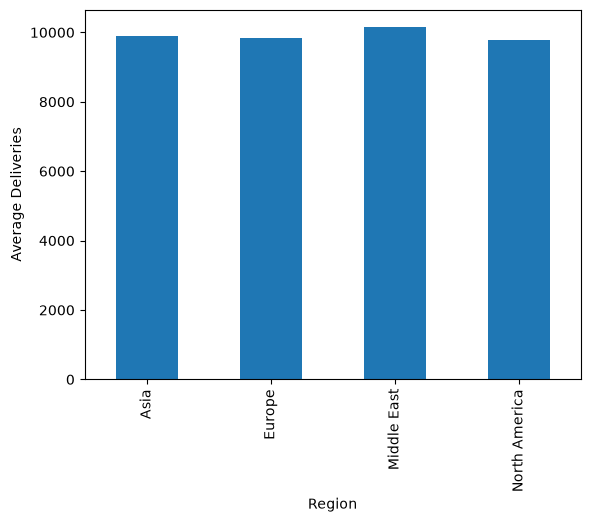

In [170]:
region_sales = df.groupby("Region")["Estimated_Deliveries"].mean()

region_sales.plot(kind="bar")

plt.ylabel("Average Deliveries")
plt.show()

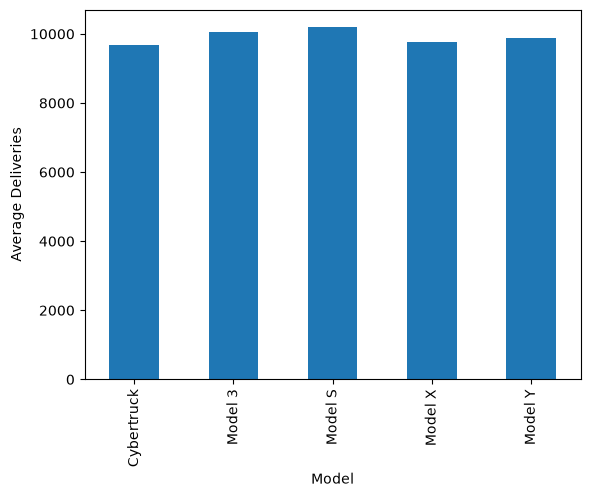

In [171]:
model_sales = df.groupby("Model")["Estimated_Deliveries"].mean()

model_sales.plot(kind="bar")

plt.ylabel("Average Deliveries")
plt.show()

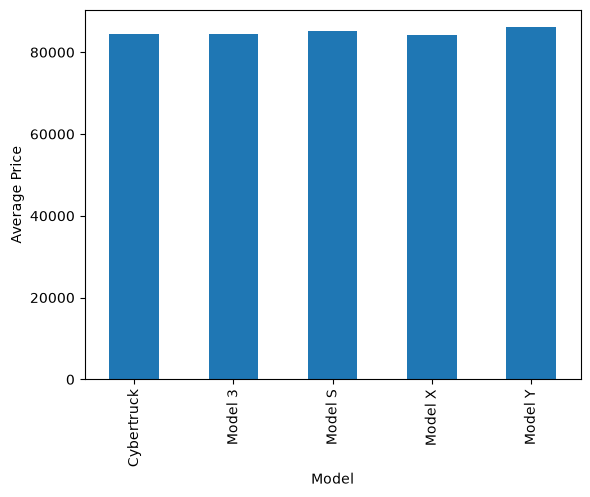

In [172]:
price_model = df.groupby("Model")["Avg_Price_USD"].mean()

price_model.plot(kind="bar")

plt.ylabel("Average Price")
plt.show()

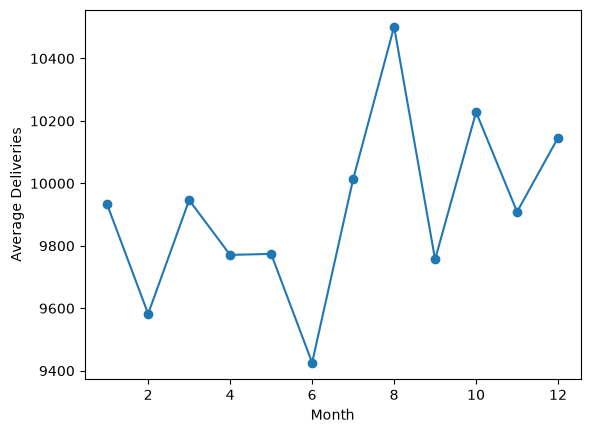

In [173]:
monthly = df.groupby("Month")["Estimated_Deliveries"].mean()

monthly.plot(marker="o")

plt.ylabel("Average Deliveries")

plt.show()

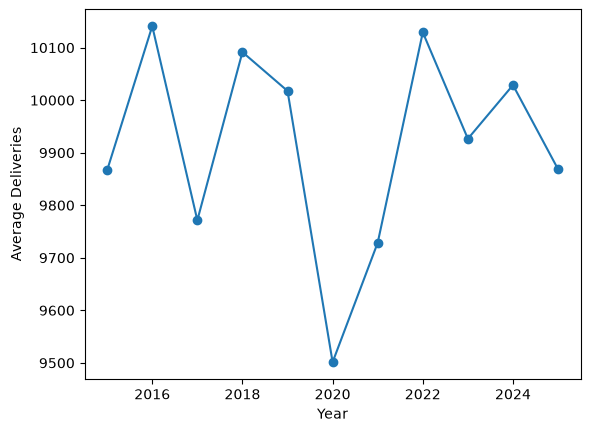

In [174]:
yearly = df.groupby("Year")["Estimated_Deliveries"].mean()

yearly.plot(marker="o")

plt.ylabel("Average Deliveries")

plt.show()

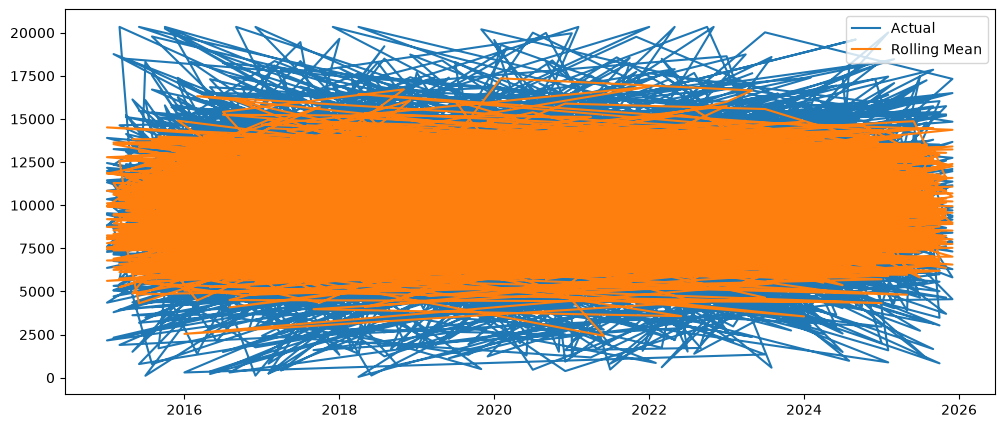

In [175]:
rolling = df["Estimated_Deliveries"].rolling(3).mean()

plt.figure(figsize=(12,5))

plt.plot(df["Date"], df["Estimated_Deliveries"], label="Actual")
plt.plot(df["Date"], rolling, label="Rolling Mean")

plt.legend()

plt.show()

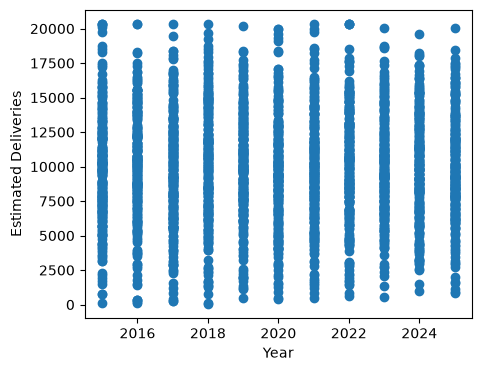

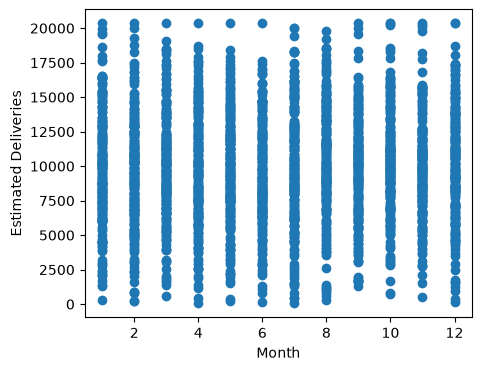

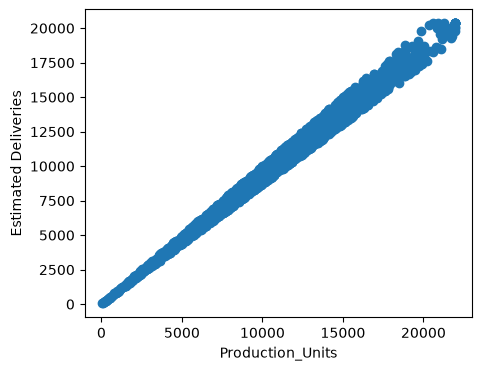

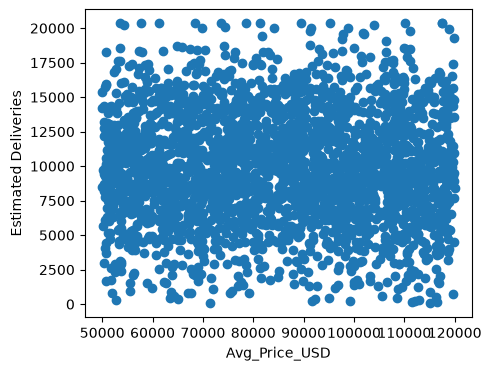

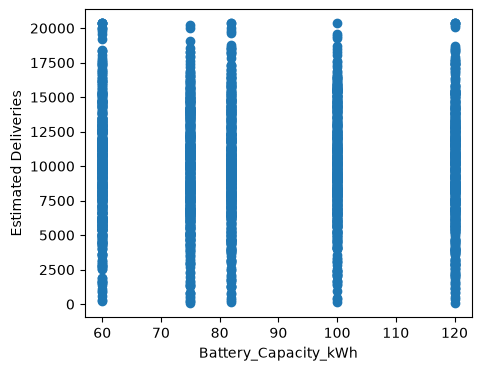

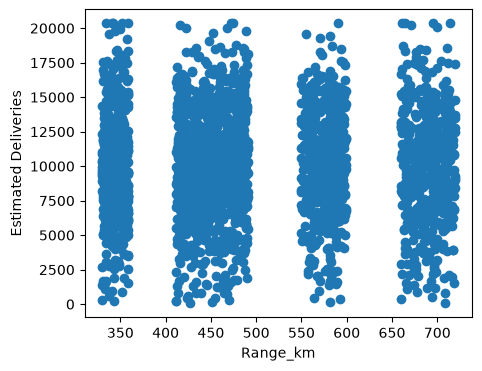

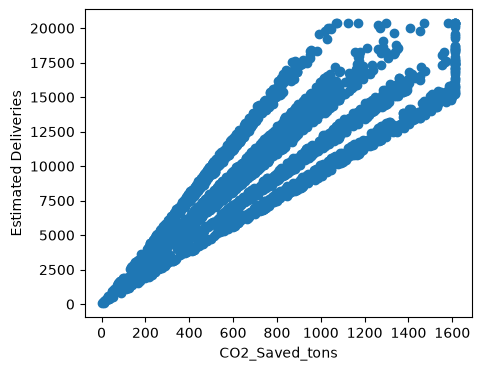

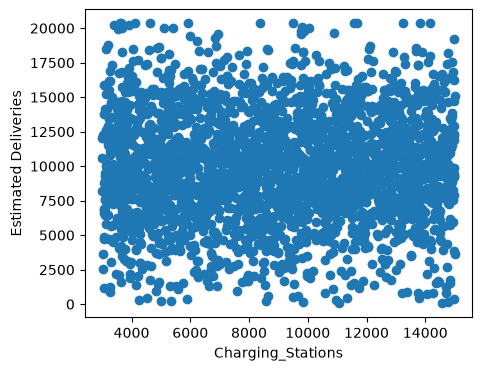

In [176]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if col != "Estimated_Deliveries":
        plt.figure(figsize=(5,4))
        plt.scatter(df[col], df["Estimated_Deliveries"])
        plt.xlabel(col)
        plt.ylabel("Estimated Deliveries")
        plt.show()

In [177]:
corr["Estimated_Deliveries"].sort_values(ascending=False)

Estimated_Deliveries    1.000000
Production_Units        0.994312
CO2_Saved_tons          0.839164
Month                   0.030730
Charging_Stations       0.001451
Year                   -0.001381
Range_km               -0.006243
Battery_Capacity_kWh   -0.007531
Avg_Price_USD          -0.026679
Name: Estimated_Deliveries, dtype: float64

In [178]:
df = df.sort_values("Date").reset_index(drop=True)

In [179]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
0,2015,1,Asia,Model Y,12446.0,13885.0,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
1,2015,1,Middle East,Model 3,11446.0,12752.0,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2,2015,1,Middle East,Cybertruck,8803.0,9344.0,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
3,2015,1,North America,Cybertruck,6367.0,6802.0,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
4,2015,1,Asia,Model 3,8795.0,9165.0,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


### FEATURE ENGG.

In [180]:
target = "CO2_Saved_tons"

X = df.drop(columns=[
    target,
    "Date"
])

y = df[target]

In [181]:
df["Quarter"] = df["Date"].dt.quarter

In [182]:
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

In [183]:
df["Efficiency"] = (
    df["Range_km"] /
    df["Battery_Capacity_kWh"]
)

In [184]:
df["Charging_Density"] = (
    df["Charging_Stations"] /
    df["Estimated_Deliveries"]
)

In [185]:
df["Production_Ratio"] = (
    df["Production_Units"] /
    df["Estimated_Deliveries"]
)

In [186]:
df["Capability_Score"] = (
    df["Battery_Capacity_kWh"] *
    df["Range_km"]
)

In [187]:
df["Infrastructure_Score"] = (
    df["Charging_Stations"] *
    df["Range_km"]
)

In [188]:
region_freq = df["Region"].value_counts()

df["Region_Freq"] = df["Region"].map(region_freq)

In [189]:
model_freq = df["Model"].value_counts()

df["Model_Freq"] = df["Model"].map(model_freq)

In [190]:
source_freq = df["Source_Type"].value_counts()

df["Source_Freq"] = df["Source_Type"].map(source_freq)

In [191]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,...,Month_sin,Month_cos,Efficiency,Charging_Density,Production_Ratio,Capability_Score,Infrastructure_Score,Region_Freq,Model_Freq,Source_Freq
0,2015,1,Asia,Model Y,12446.0,13885.0,55183.13,60,340,634.75,...,0.5,0.866025,5.666667,0.352724,1.115619,20400,1492600,660,528,884
1,2015,1,Middle East,Model 3,11446.0,12752.0,89289.40,100,588,1009.54,...,0.5,0.866025,5.880000,0.779748,1.114101,58800,5247900,660,528,872
2,2015,1,Middle East,Cybertruck,8803.0,9344.0,102888.58,60,336,443.67,...,0.5,0.866025,5.600000,0.445644,1.061456,20160,1318128,660,528,884
3,2015,1,North America,Cybertruck,6367.0,6802.0,104962.32,82,459,438.37,...,0.5,0.866025,5.597561,1.440239,1.068321,37638,4209030,660,528,872
4,2015,1,Asia,Model 3,8795.0,9165.0,87988.73,82,456,601.58,...,0.5,0.866025,5.560976,1.435588,1.042069,37392,5757456,660,528,884


In [192]:
target = "CO2_Saved_tons"

X = df.drop(columns=[target, "Date"])
y = df[target]

### TRAIN_TEST SPLIT

In [194]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### DATA PRECESSING PIPELINE

In [195]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(
    [
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

### LINEAR REGRESSION

In [211]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

y_pred_lr = linear_pipeline.predict(X_test)

mae=round(mean_absolute_error(y_test, y_pred_lr), 2)
rmse=round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 2)
r2=round(r2_score(y_test, y_pred_lr), 4)
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

MAE : 49.11
RMSE: 71.91
R²  : 0.959


### RIDGE REGRESSION

In [212]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

In [213]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

In [214]:
param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

In [215]:
grid_ridge = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_ridge.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...l', Ridge())])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [216]:
print("Best Alpha:", grid_ridge.best_params_)

Best Alpha: {'model__alpha': 1}


In [217]:
y_pred_ridge = grid_ridge.predict(X_test)

In [218]:
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"MAE : {mae_ridge:.2f}")
print(f"RMSE: {rmse_ridge:.2f}")
print(f"R²  : {r2_ridge:.4f}")

MAE : 49.14
RMSE: 72.05
R²  : 0.9588


### LASSO REGRESSION

In [219]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=5000))
])

In [220]:
param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10]
}

In [221]:
grid_lasso = GridSearchCV(
    lasso_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

grid_lasso.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=5000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__alpha': [0.001, 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting

In [222]:
print("Best Alpha:", grid_lasso.best_params_)

Best Alpha: {'model__alpha': 1}


In [223]:
y_pred_lasso = grid_lasso.predict(X_test)

In [224]:
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"MAE : {mae_lasso:.2f}")
print(f"RMSE: {rmse_lasso:.2f}")
print(f"R²  : {r2_lasso:.4f}")

MAE : 49.09
RMSE: 71.76
R²  : 0.9591


### MODEL COMPARISON

In [225]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression", "Lasso Regression"],
    "MAE": [mae, mae_ridge, mae_lasso],
    "RMSE": [rmse, rmse_ridge, rmse_lasso],
    "R²": [r2, r2_ridge, r2_lasso]
})

comparison.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
2,Lasso Regression,49.090043,71.761776,0.959140
0,Linear Regression,49.110000,71.910000,0.959000
1,Ridge Regression,49.143729,72.048231,0.958813


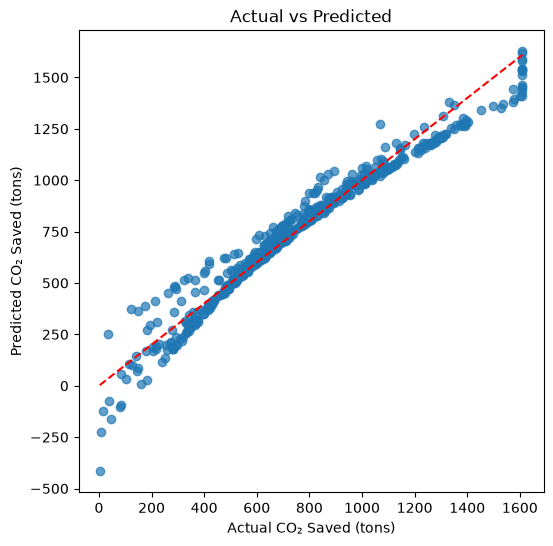

In [226]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_ridge, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--"
)

plt.xlabel("Actual CO₂ Saved (tons)")
plt.ylabel("Predicted CO₂ Saved (tons)")
plt.title("Actual vs Predicted")

plt.show()

### CROSS VALIDATION

In [227]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    grid_lasso.best_estimator_,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

print("Cross Validation R² Scores:")
print(cv_scores)

print("\nMean R²:", round(cv_scores.mean(), 4))

Cross Validation R² Scores:
[0.96361056 0.95558985 0.96316798 0.96001557 0.96107774]

Mean R²: 0.9607


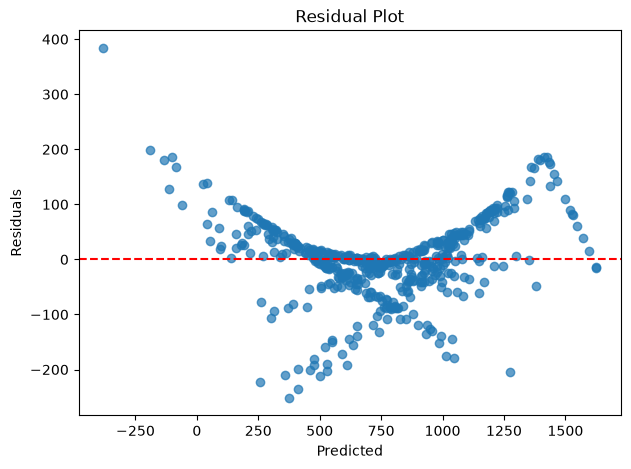

In [228]:
residuals = y_test - y_pred_lasso

plt.figure(figsize=(7,5))
plt.scatter(y_pred_lasso, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

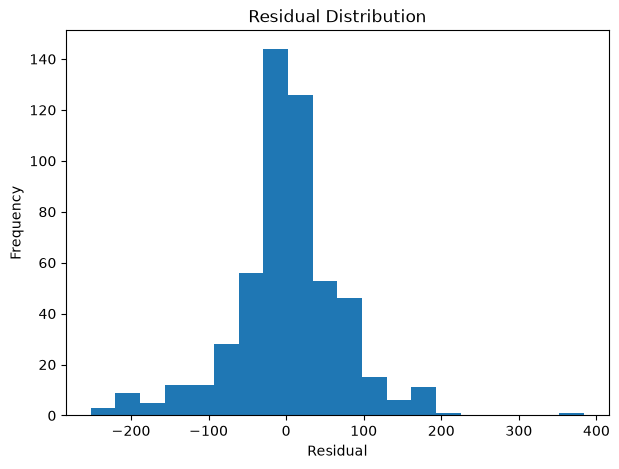

In [229]:
plt.figure(figsize=(7,5))
plt.hist(residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

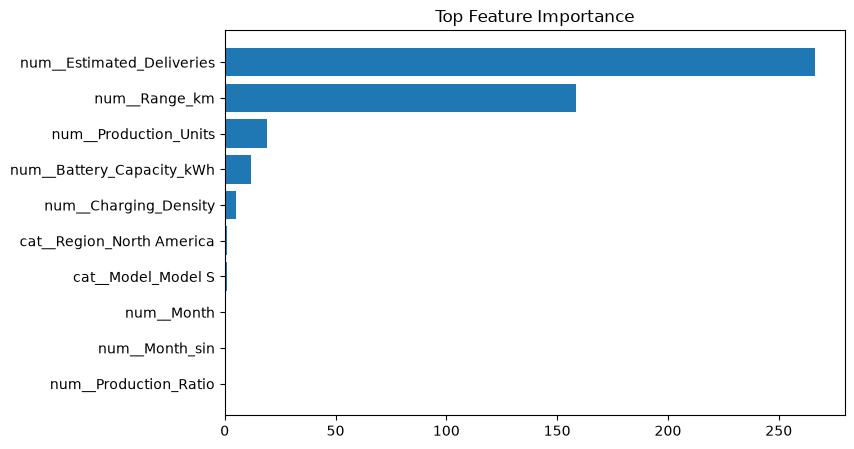

In [232]:
feature_names = preprocessor.get_feature_names_out()

coef = grid_lasso.best_estimator_.named_steps["model"].coef_

importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coef
})

importance["Abs_Coefficient"] = importance["Coefficient"].abs()

importance.sort_values(
    "Abs_Coefficient",
    ascending=False
).head(10)

top = importance.sort_values(
    "Abs_Coefficient",
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(top["Feature"], top["Abs_Coefficient"])

plt.title("Top Feature Importance")

plt.gca().invert_yaxis()

plt.show()

## TIME SERIES FORECASTING

In [244]:
ts = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .reset_index()
      .sort_values("Date")
)

ts.head()

,Date,Estimated_Deliveries
0,2015-01-01,183180.000
1,2015-02-01,165053.000
2,2015-03-01,179494.625
3,2015-04-01,225623.000
4,2015-05-01,184264.000


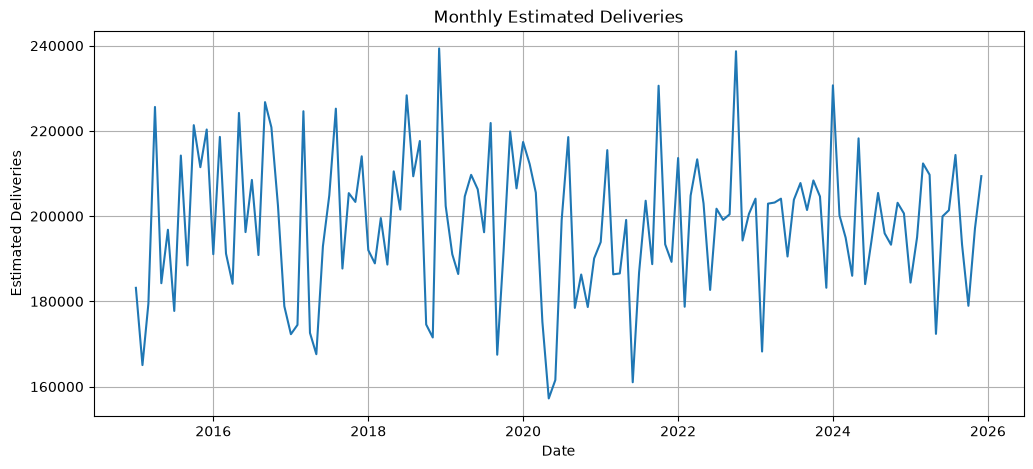

In [245]:
plt.figure(figsize=(12,5))

plt.plot(ts["Date"], ts["Estimated_Deliveries"])

plt.title("Monthly Estimated Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

In [246]:
ts["Rolling_Mean"] = (
    ts["Estimated_Deliveries"]
    .rolling(12)
    .mean()
)

ts["Rolling_STD"] = (
    ts["Estimated_Deliveries"]
    .rolling(12)
    .std()
)

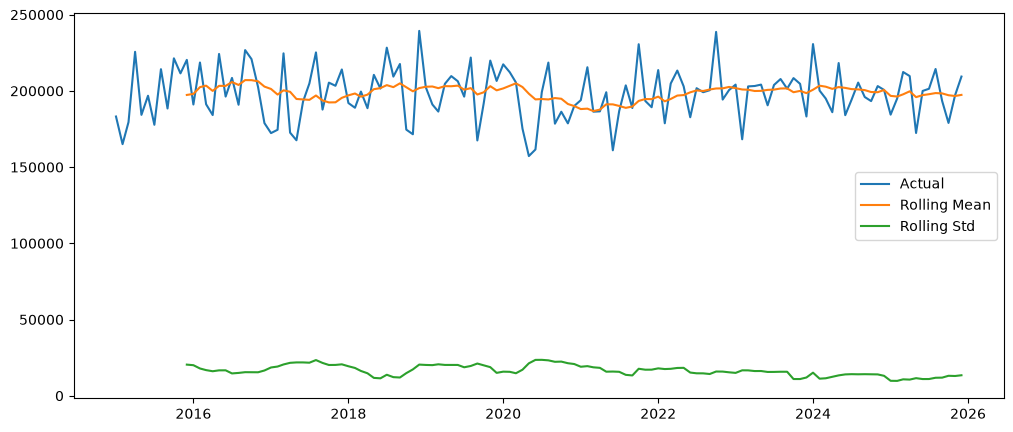

In [247]:
plt.figure(figsize=(12,5))

plt.plot(ts["Date"], ts["Estimated_Deliveries"], label="Actual")
plt.plot(ts["Date"], ts["Rolling_Mean"], label="Rolling Mean")
plt.plot(ts["Date"], ts["Rolling_STD"], label="Rolling Std")

plt.legend()

plt.show()

In [248]:
ts["Lag_1"] = ts["Estimated_Deliveries"].shift(1)
ts["Lag_3"] = ts["Estimated_Deliveries"].shift(3)
ts["Lag_6"] = ts["Estimated_Deliveries"].shift(6)
ts["Lag_12"] = ts["Estimated_Deliveries"].shift(12)

ts = ts.dropna()

In [249]:
split = int(len(ts) * 0.8)

train = ts.iloc[:split]
test = ts.iloc[split:]

In [250]:
features = [
    "Lag_1",
    "Lag_3",
    "Lag_6",
    "Lag_12",
    "Rolling_Mean",
    "Rolling_STD"
]

X_train = train[features]
y_train = train["Estimated_Deliveries"]

X_test = test[features]
y_test = test["Estimated_Deliveries"]

In [251]:
from sklearn.ensemble import RandomForestRegressor

forecast_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forecast_model.fit(X_train, y_train)

forecast = forecast_model.predict(X_test)

In [252]:
print("MAE :", mean_absolute_error(y_test, forecast))
print("RMSE:", np.sqrt(mean_squared_error(y_test, forecast)))
print("R²  :", r2_score(y_test, forecast))

MAE : 10230.742630208331
RMSE: 12620.27399119926
R²  : 0.026979273167133444


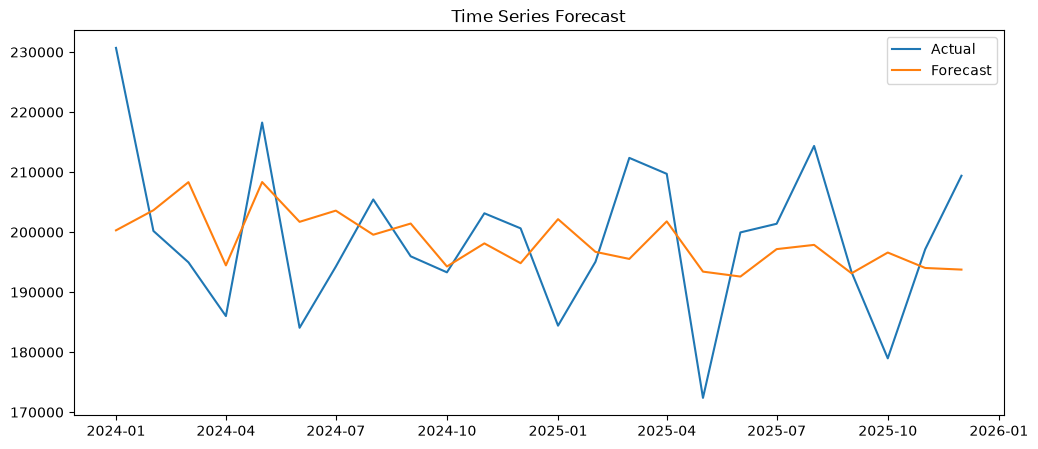

In [253]:
plt.figure(figsize=(12,5))

plt.plot(
    test["Date"],
    y_test,
    label="Actual"
)

plt.plot(
    test["Date"],
    forecast,
    label="Forecast"
)

plt.legend()

plt.title("Time Series Forecast")

plt.show()

In [254]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts["Estimated_Deliveries"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1] < 0.05:
    print("Series is stationary")
else:
    print("Series is non-stationary")

ADF Statistic : -8.605909078413385
p-value : 6.673653999139912e-14
Series is stationary
